In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
data=pd.read_csv("medical-charges.csv")

In [ ]:
data.head(50)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
data.shape


(1338, 7)

In [ ]:
data.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
import seaborn as sns

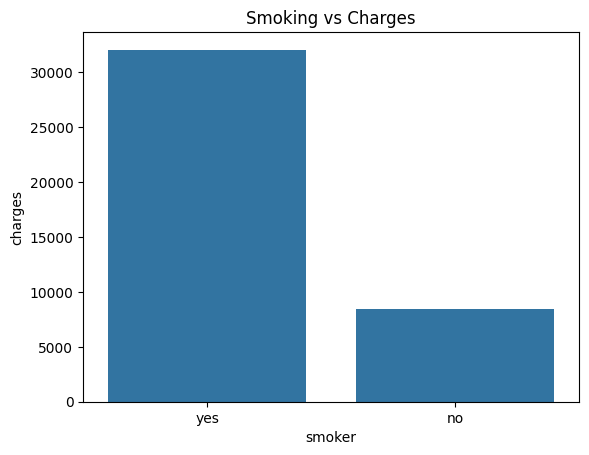

In [ ]:
sns.barplot(x='smoker', y='charges', data=data, estimator='mean', errorbar=None)
plt.title('Smoking vs Charges')
plt.show()

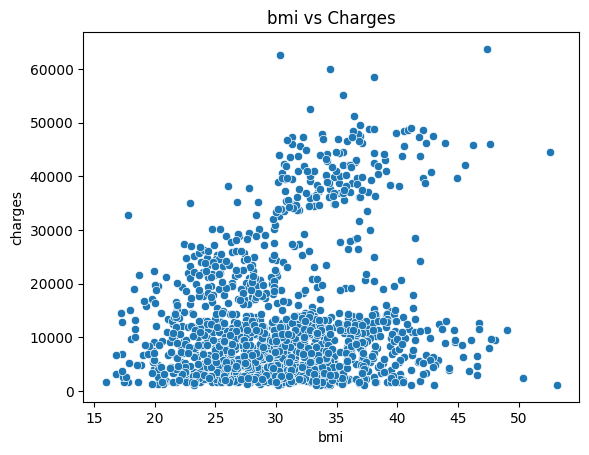

In [ ]:
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title('bmi vs Charges')
plt.show()

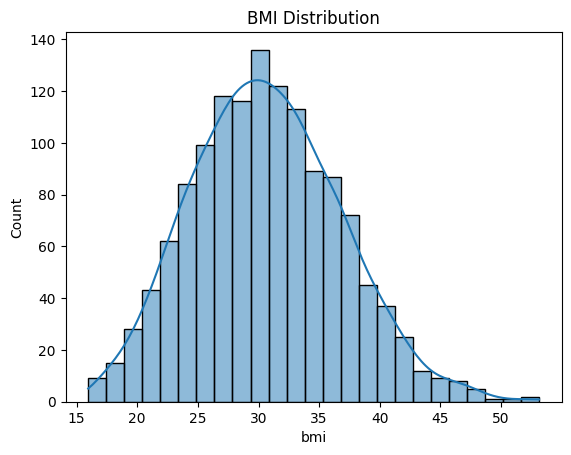

In [ ]:
sns.histplot(data['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()

In [ ]:
data.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
y=data.charges
features=['age','sex','bmi','region','smoker','children']
X=data[features]

In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

In [ ]:
train_X = pd.get_dummies(train_X, drop_first=True)
val_X = pd.get_dummies(val_X, drop_first=True)

# Align columns - crucial for consistent feature sets
val_X = val_X.reindex(columns=train_X.columns, fill_value=0)

price_model=DecisionTreeRegressor(random_state=1)
price_model.fit(train_X,train_y)

DecisionTreeRegressor(random_state=1)

In [ ]:
val_predictions = price_model.predict(val_X)
val_mae = mean_absolute_error(val_predictions, val_y)


In [ ]:
print(val_predictions)


[ 1263.249   11842.62375  8457.818   10977.2063   1964.78    39983.42595
  8978.1851  11658.37915  2483.736   20149.3229  13451.122   12105.32
  6238.298    7640.3092   1137.011   10141.1362   4571.41305  6746.7425
 12333.828   13470.86     9140.951   39241.442    7731.85785  8827.2099
 21344.8467   6393.60345  8522.003    8280.6227  14358.36437  2866.091
 11763.0009   5003.853   22218.1149  36898.73308 21978.6769  10422.91665
 44585.45587 16232.847   24227.33724 40974.1649  18903.49141 12231.6136
 10702.6424  12333.828    4719.52405 13143.86485  1391.5287  37270.1512
  9566.9909  13430.265   13143.86485 12105.32     2395.17155 26236.57997
 16232.847    4320.41085 40974.1649  12638.195    3484.331    1146.7966
  3268.84665 13143.86485 35147.52848  2850.68375 13228.84695  8964.06055
 10600.5483  12044.342    2710.82855 13747.87235 44641.1974  36950.2567
  1744.465   12475.3513  13844.7972  42124.5153   3309.7926   2866.091
 11837.16     9282.4806   2585.269   12495.29085 25517.11363  19

In [ ]:
print(val_mae)

3334.3237347761196


In [ ]:
train_predictions = price_model.predict(train_X)
train_mae = mean_absolute_error(train_predictions, train_y)
print(train_mae)

0.0
